# Deception & Error Analysis

## Overview
This notebook provides a comprehensive post-game analysis of deception patterns and operational errors across the 3-game experiment. It combines:

1. **LLM Deception Analysis** — Scores produced by `deception_analyzer.py`, which uses an LLM to compare each power's private diary, public messages, and actual orders to classify deceptive behaviour.
2. **Error & Reliability Analysis** — Extracted from `llm_responses.csv`, covering invalid orders, JSON parse failures, authentication errors, and model-level reliability.

### Prerequisites
Run the deception analyzer first to generate `deception_scores.csv`:
```bash
python deception_analyzer.py results/3game_experiment/ --model "openrouter:x-ai/grok-4.1-fast"
```

In [1]:
import pandas as pd
import json
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")

base_path = os.path.join(os.path.dirname(os.getcwd()), "results", "3game_experiment")
games = ["game1", "game2", "game3"]

# ── Load game data ──
game_data_all = {}
game_id_to_name = {}
for game in games:
    path = os.path.join(base_path, game, "lmvsgame.json")
    if os.path.exists(path):
        with open(path, "r") as f:
            gdata = json.load(f)
        game_data_all[game] = gdata
        raw_id = gdata.get("id")
        if raw_id:
            game_id_to_name[str(raw_id)] = game

# ── Load experiment summary ──
with open(os.path.join(base_path, "experiment_summary.json"), "r") as f:
    summary_data = json.load(f)

# Power -> model mapping
model_mapping = []
for game_name, game_info in summary_data["results"].items():
    if "power_model_map" in game_info:
        for power, model in game_info["power_model_map"].items():
            model_mapping.append({"game": game_name, "power": power, "model_name": model})
model_df = pd.DataFrame(model_mapping)

# Supply center outcomes
sc_data = []
for game_name, game_info in summary_data["results"].items():
    if "supply_centers" in game_info:
        for power, sc_info in game_info["supply_centers"].items():
            sc_data.append({"game": game_name, "power": power, "final_sc": sc_info["count"],
                            "eliminated": sc_info.get("eliminated", False)})
sc_df = pd.DataFrame(sc_data)

# ── Load LLM response logs ──
all_responses = []
for game in games:
    csv_path = os.path.join(base_path, game, "llm_responses.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df["game"] = game
        all_responses.append(df)

resp_df = pd.concat(all_responses, ignore_index=True)
print(f"Loaded {len(resp_df)} LLM response records across {resp_df['game'].nunique()} games")

# ── Load deception scores (if available) ──
deception_csv = os.path.join(base_path, "deception_scores.csv")
has_deception = os.path.exists(deception_csv)
if has_deception:
    dec_df = pd.read_csv(deception_csv)
    dec_df["game"] = dec_df["game_id"].map(game_id_to_name)
    dec_df = dec_df.dropna(subset=["game"])
    print(f"Loaded {len(dec_df)} deception analysis records")
    print(f"  Game ID mapping: {game_id_to_name}")
else:
    print("WARNING: deception_scores.csv not found. Run deception_analyzer.py first.")
    print("Deception sections will be skipped. Error analysis will still work.")
    dec_df = pd.DataFrame()

print(f"Loaded {len(game_data_all)} games")
print(f"Model mapping: {len(model_df)} entries across {model_df['game'].nunique()} games")
print(f"SC outcomes: {len(sc_df)} entries across {sc_df['game'].nunique()} games")

Loaded 2584 LLM response records across 3 games
Loaded 401 deception analysis records
  Game ID mapping: {'JuF6LGzS5tAez409': 'game1', 'X4ICMGXX-ojdCP76': 'game2', 'iJEph8--VZIVXgBZ': 'game3'}
Loaded 3 games
Model mapping: 21 entries across 3 games
SC outcomes: 21 entries across 3 games


---
# Part 1: Deception Analysis
The deception analyzer compares each power's **private diary** (true intentions), **public messages** (what they told others), and **actual orders** (what they did) to produce a deception score (0.0 = fully honest, 1.0 = fully deceptive) and a classification.

## 1.1 Deception Score Distribution
How deceptive were the agents overall? We look at the distribution of deception scores across all power/phase combinations.

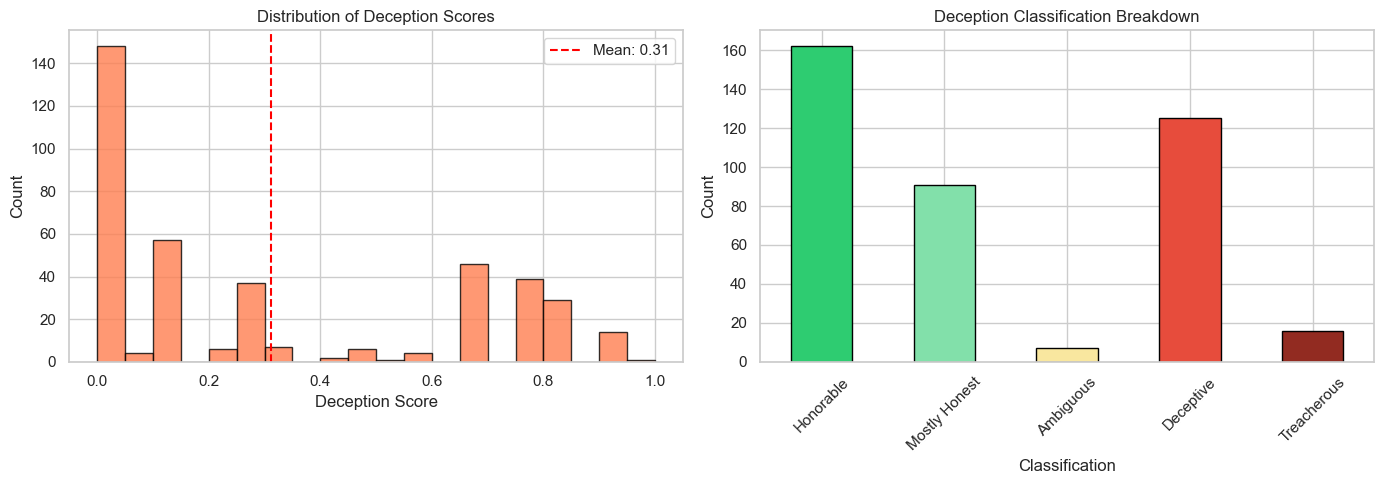


Summary Statistics:
  Total analysed:  401
  Mean deception:  0.311
  Median:          0.150
  Std dev:         0.334
  Parse errors:    0


In [2]:
if has_deception:
    valid_dec = dec_df[dec_df["deception_score"] >= 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram of deception scores
    axes[0].hist(valid_dec["deception_score"], bins=20, edgecolor="black", color="coral", alpha=0.8)
    axes[0].set_xlabel("Deception Score")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Deception Scores")
    axes[0].axvline(valid_dec["deception_score"].mean(), color="red", linestyle="--",
                    label=f"Mean: {valid_dec['deception_score'].mean():.2f}")
    axes[0].legend()

    # Classification counts
    class_order = ["Honorable", "Mostly Honest", "Ambiguous", "Deceptive", "Treacherous"]
    class_counts = valid_dec["classification"].value_counts().reindex(class_order, fill_value=0)
    colors = ["#2ecc71", "#82e0aa", "#f9e79f", "#e74c3c", "#922b21"]
    class_counts.plot(kind="bar", ax=axes[1], color=colors[:len(class_counts)], edgecolor="black")
    axes[1].set_xlabel("Classification")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Deception Classification Breakdown")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    print(f"\nSummary Statistics:")
    print(f"  Total analysed:  {len(valid_dec)}")
    print(f"  Mean deception:  {valid_dec['deception_score'].mean():.3f}")
    print(f"  Median:          {valid_dec['deception_score'].median():.3f}")
    print(f"  Std dev:         {valid_dec['deception_score'].std():.3f}")
    print(f"  Parse errors:    {(dec_df['classification'] == 'PARSE_ERROR').sum()}")
else:
    print("Skipped: deception_scores.csv not available.")

## 1.2 Deception Trajectories Over Time
How does deception evolve as the game progresses? Early game alliances may start honest, but as the board contracts, deception should increase.

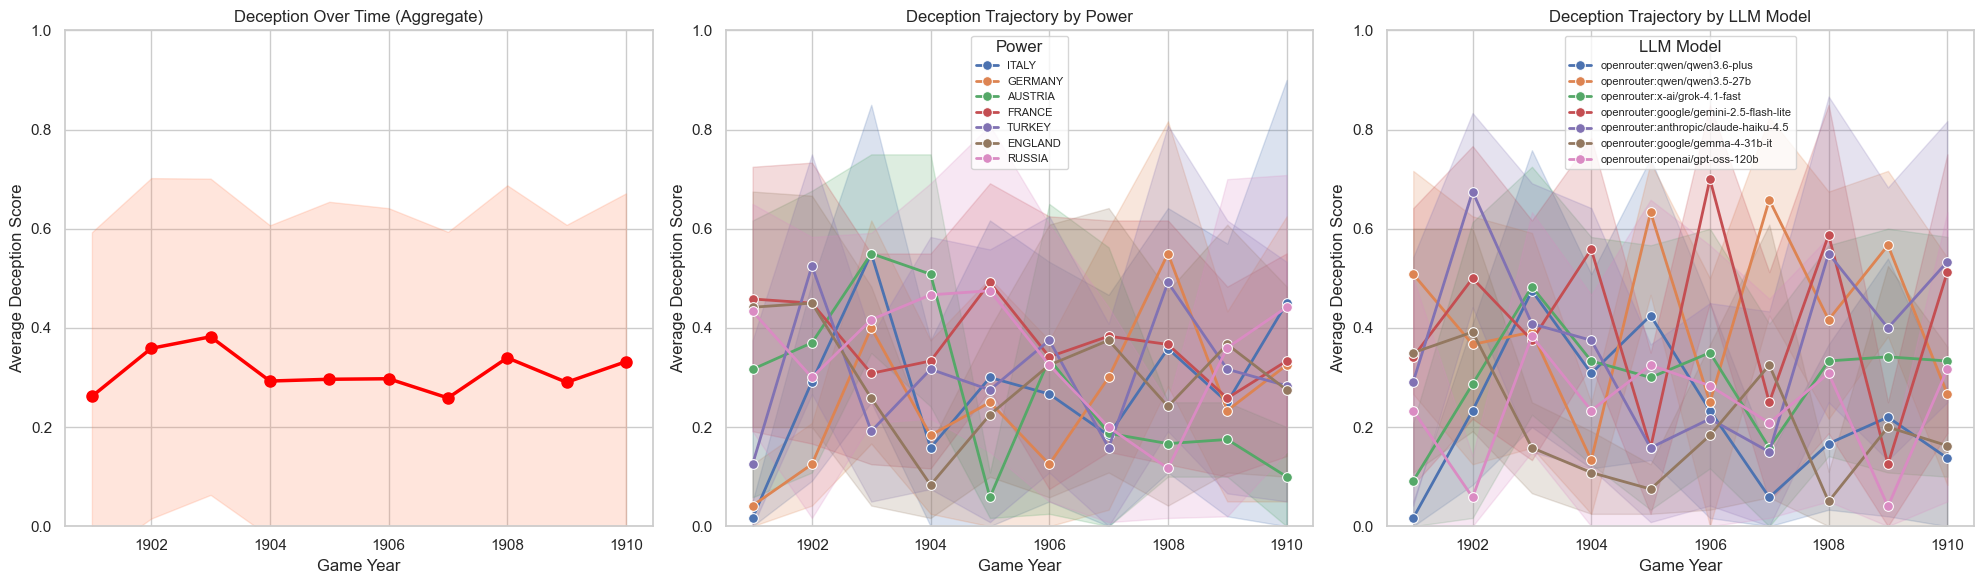

In [3]:
if has_deception:
    valid_dec["year"] = valid_dec["phase"].str.extract(r"(19\d{2})").astype(float)
    dec_with_model = pd.merge(valid_dec, model_df, on=["game", "power"], how="inner")

    # Aggregate trajectory
    year_avg = valid_dec.groupby("year")["deception_score"].agg(["mean", "std", "count"]).reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    axes[0].fill_between(year_avg["year"], year_avg["mean"] - year_avg["std"],
                         year_avg["mean"] + year_avg["std"], alpha=0.2, color="coral")
    axes[0].plot(year_avg["year"], year_avg["mean"], marker="o", color="red", linewidth=2.5, markersize=8)
    axes[0].set_xlabel("Game Year")
    axes[0].set_ylabel("Average Deception Score")
    axes[0].set_title("Deception Over Time (Aggregate)")
    axes[0].set_ylim(0, 1)

    # By power
    sns.lineplot(data=valid_dec, x="year", y="deception_score", hue="power",
                 marker="o", linewidth=2, markersize=7, ax=axes[1])
    axes[1].set_xlabel("Game Year")
    axes[1].set_ylabel("Average Deception Score")
    axes[1].set_title("Deception Trajectory by Power")
    axes[1].set_ylim(0, 1)
    axes[1].legend(title="Power", fontsize=8)

    # By model
    sns.lineplot(data=dec_with_model, x="year", y="deception_score", hue="model_name",
                 marker="o", linewidth=2, markersize=7, ax=axes[2])
    axes[2].set_xlabel("Game Year")
    axes[2].set_ylabel("Average Deception Score")
    axes[2].set_title("Deception Trajectory by LLM Model")
    axes[2].set_ylim(0, 1)
    axes[2].legend(title="LLM Model", fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("Skipped: deception_scores.csv not available.")

## 1.3 Deception by Power
Which powers are the most deceptive? This may reflect the strategic position of the power (e.g. central powers needing to play both sides) or the personality of the underlying LLM.

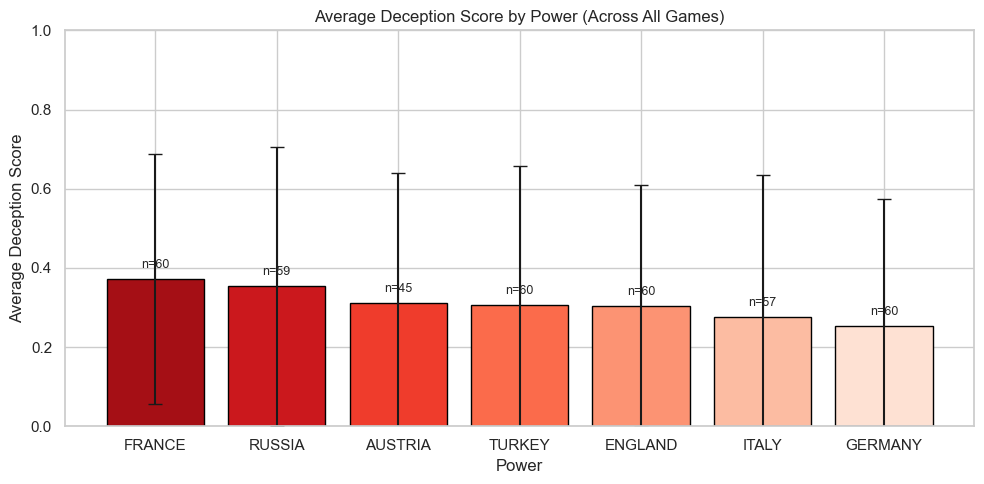

In [4]:
if has_deception:
    power_dec = valid_dec.groupby("power")["deception_score"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False).reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(power_dec["power"], power_dec["mean"], yerr=power_dec["std"],
                  capsize=5, color=sns.color_palette("Reds_r", len(power_dec)), edgecolor="black")
    ax.set_ylabel("Average Deception Score")
    ax.set_xlabel("Power")
    ax.set_title("Average Deception Score by Power (Across All Games)")
    ax.set_ylim(0, 1)
    for bar, count in zip(bars, power_dec["count"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"n={count}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: deception_scores.csv not available.")

## 1.4 Deception by LLM Model
Are certain LLM architectures more deceptive than others? Since powers rotate across games, we can isolate the effect of the model from the strategic position.

Joined 401 deception records with model info


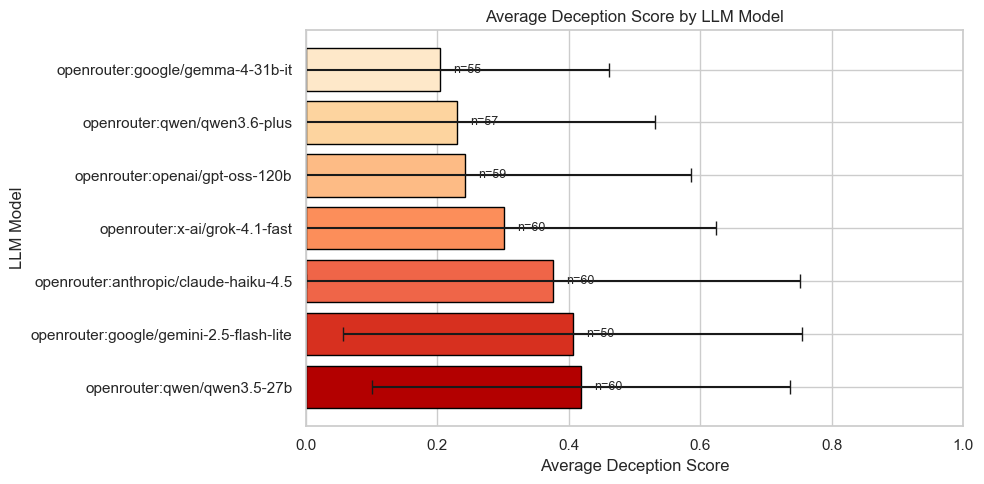

                             model_name     mean      std  count
            openrouter:qwen/qwen3.5-27b 0.419167 0.317844     60
openrouter:google/gemini-2.5-flash-lite 0.406000 0.348560     50
  openrouter:anthropic/claude-haiku-4.5 0.375833 0.375239     60
          openrouter:x-ai/grok-4.1-fast 0.301167 0.323561     60
         openrouter:openai/gpt-oss-120b 0.242373 0.343764     59
           openrouter:qwen/qwen3.6-plus 0.230702 0.299963     57
       openrouter:google/gemma-4-31b-it 0.204545 0.257350     55


In [5]:
if has_deception:
    dec_with_model = pd.merge(valid_dec, model_df, on=["game", "power"], how="inner")
    print(f"Joined {len(dec_with_model)} deception records with model info")

    model_dec = dec_with_model.groupby("model_name")["deception_score"].agg(
        ["mean", "std", "count"]).sort_values("mean", ascending=False).reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(model_dec["model_name"], model_dec["mean"],
                   xerr=model_dec["std"], capsize=5,
                   color=sns.color_palette("OrRd_r", len(model_dec)), edgecolor="black")
    ax.set_xlabel("Average Deception Score")
    ax.set_ylabel("LLM Model")
    ax.set_title("Average Deception Score by LLM Model")
    ax.set_xlim(0, 1)
    for bar, count in zip(bars, model_dec["count"]):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                f"n={count}", ha="left", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

    print(model_dec.to_string(index=False))
else:
    print("Skipped: deception_scores.csv not available.")

## 1.5 Does Deception Pay Off?
**Hypothesis:** Do more deceptive powers end up with more supply centers? A positive correlation would suggest deception is a winning strategy.

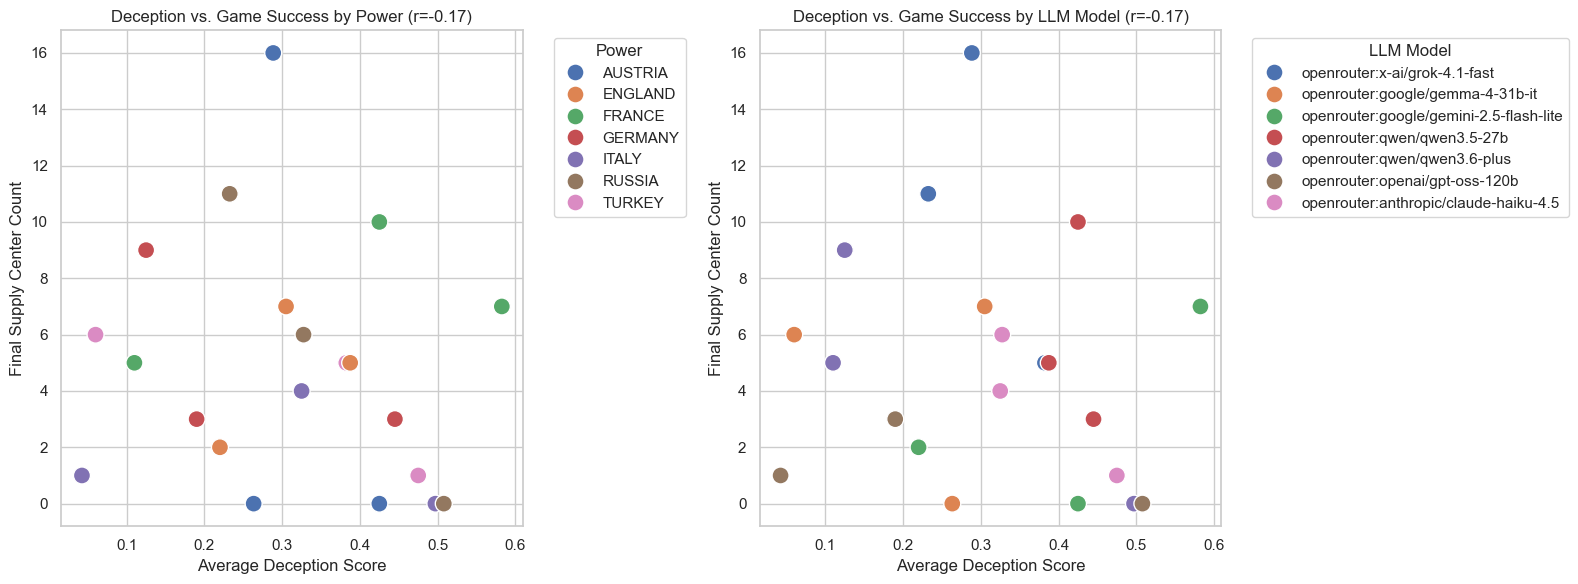

Correlation (deception vs supply centers):
  By power: r = -0.17
  By model: r = -0.17


In [6]:
if has_deception:
    avg_dec_by_power = valid_dec.groupby(["game", "power"])["deception_score"].mean().reset_index()
    avg_dec_by_power.rename(columns={"deception_score": "avg_deception"}, inplace=True)

    dec_outcome = pd.merge(avg_dec_by_power, sc_df, on=["game", "power"])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # By power
    sns.scatterplot(data=dec_outcome, x="avg_deception", y="final_sc", hue="power", s=150, ax=axes[0])
    corr_p = dec_outcome["avg_deception"].corr(dec_outcome["final_sc"])
    axes[0].set_xlabel("Average Deception Score")
    axes[0].set_ylabel("Final Supply Center Count")
    axes[0].set_title(f"Deception vs. Game Success by Power (r={corr_p:.2f})")
    axes[0].legend(title="Power", bbox_to_anchor=(1.05, 1), loc="upper left")

    # By model
    dec_outcome_model = pd.merge(dec_outcome, model_df, on=["game", "power"], how="inner")
    sns.scatterplot(data=dec_outcome_model, x="avg_deception", y="final_sc",
                    hue="model_name", s=150, ax=axes[1])
    corr_m = dec_outcome_model["avg_deception"].corr(dec_outcome_model["final_sc"])
    axes[1].set_xlabel("Average Deception Score")
    axes[1].set_ylabel("Final Supply Center Count")
    axes[1].set_title(f"Deception vs. Game Success by LLM Model (r={corr_m:.2f})")
    axes[1].legend(title="LLM Model", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

    print(f"Correlation (deception vs supply centers):")
    print(f"  By power: r = {corr_p:.2f}")
    print(f"  By model: r = {corr_m:.2f}")
else:
    print("Skipped: deception_scores.csv not available.")

## 1.6 Promise Analysis: Broken vs. Kept
The deception analyzer extracts specific broken and kept promises. What is the overall promise-keeping rate, and which powers are the most reliable?

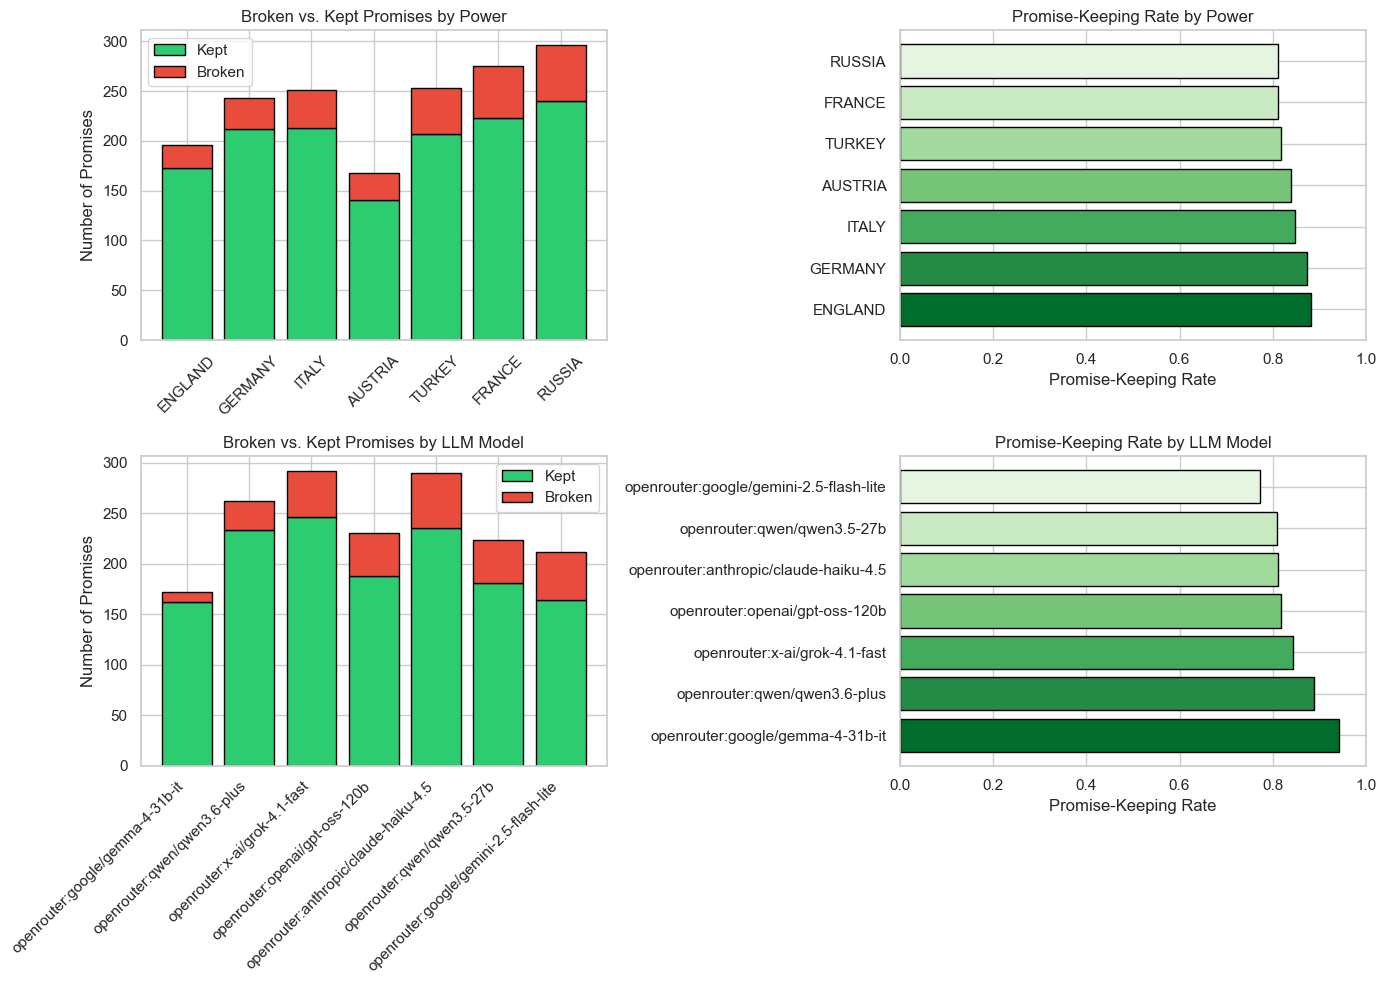


Overall: 1409 kept, 273 broken
Global promise-keeping rate: 83.8%


In [7]:
if has_deception:
    def safe_json_list(val):
        if pd.isna(val):
            return []
        try:
            result = json.loads(val)
            return result if isinstance(result, list) else []
        except (json.JSONDecodeError, TypeError):
            return []

    valid_dec["broken_list"] = valid_dec["broken_promises"].apply(safe_json_list)
    valid_dec["kept_list"] = valid_dec["kept_promises"].apply(safe_json_list)
    valid_dec["n_broken"] = valid_dec["broken_list"].apply(len)
    valid_dec["n_kept"] = valid_dec["kept_list"].apply(len)

    # By power
    promise_by_power = valid_dec.groupby("power").agg(
        total_broken=("n_broken", "sum"), total_kept=("n_kept", "sum")
    ).reset_index()
    promise_by_power["total"] = promise_by_power["total_broken"] + promise_by_power["total_kept"]
    promise_by_power["kept_rate"] = promise_by_power["total_kept"] / promise_by_power["total"].replace(0, np.nan)
    promise_by_power = promise_by_power.sort_values("kept_rate", ascending=False)

    # By model
    dec_promises = pd.merge(valid_dec, model_df, on=["game", "power"], how="inner")
    promise_by_model = dec_promises.groupby("model_name").agg(
        total_broken=("n_broken", "sum"), total_kept=("n_kept", "sum")
    ).reset_index()
    promise_by_model["total"] = promise_by_model["total_broken"] + promise_by_model["total_kept"]
    promise_by_model["kept_rate"] = promise_by_model["total_kept"] / promise_by_model["total"].replace(0, np.nan)
    promise_by_model = promise_by_model.sort_values("kept_rate", ascending=False)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Power: stacked bar
    x = range(len(promise_by_power))
    axes[0, 0].bar(x, promise_by_power["total_kept"], label="Kept", color="#2ecc71", edgecolor="black")
    axes[0, 0].bar(x, promise_by_power["total_broken"], bottom=promise_by_power["total_kept"],
                   label="Broken", color="#e74c3c", edgecolor="black")
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(promise_by_power["power"], rotation=45)
    axes[0, 0].set_ylabel("Number of Promises")
    axes[0, 0].set_title("Broken vs. Kept Promises by Power")
    axes[0, 0].legend()

    # Power: keeping rate
    axes[0, 1].barh(promise_by_power["power"], promise_by_power["kept_rate"].fillna(0),
                    color=sns.color_palette("Greens_r", len(promise_by_power)), edgecolor="black")
    axes[0, 1].set_xlabel("Promise-Keeping Rate")
    axes[0, 1].set_title("Promise-Keeping Rate by Power")
    axes[0, 1].set_xlim(0, 1)

    # Model: stacked bar
    x_m = range(len(promise_by_model))
    axes[1, 0].bar(x_m, promise_by_model["total_kept"], label="Kept", color="#2ecc71", edgecolor="black")
    axes[1, 0].bar(x_m, promise_by_model["total_broken"], bottom=promise_by_model["total_kept"],
                   label="Broken", color="#e74c3c", edgecolor="black")
    axes[1, 0].set_xticks(x_m)
    axes[1, 0].set_xticklabels(promise_by_model["model_name"], rotation=45, ha="right")
    axes[1, 0].set_ylabel("Number of Promises")
    axes[1, 0].set_title("Broken vs. Kept Promises by LLM Model")
    axes[1, 0].legend()

    # Model: keeping rate
    axes[1, 1].barh(promise_by_model["model_name"], promise_by_model["kept_rate"].fillna(0),
                    color=sns.color_palette("Greens_r", len(promise_by_model)), edgecolor="black")
    axes[1, 1].set_xlabel("Promise-Keeping Rate")
    axes[1, 1].set_title("Promise-Keeping Rate by LLM Model")
    axes[1, 1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

    total_broken = valid_dec["n_broken"].sum()
    total_kept = valid_dec["n_kept"].sum()
    print(f"\nOverall: {total_kept} kept, {total_broken} broken")
    if total_broken + total_kept > 0:
        print(f"Global promise-keeping rate: {total_kept / (total_broken + total_kept):.1%}")
else:
    print("Skipped: deception_scores.csv not available.")

## 1.7 Deception Heatmap: Power vs. Game Phase
A heatmap showing deception intensity per power per year reveals when and where diplomatic betrayals cluster.

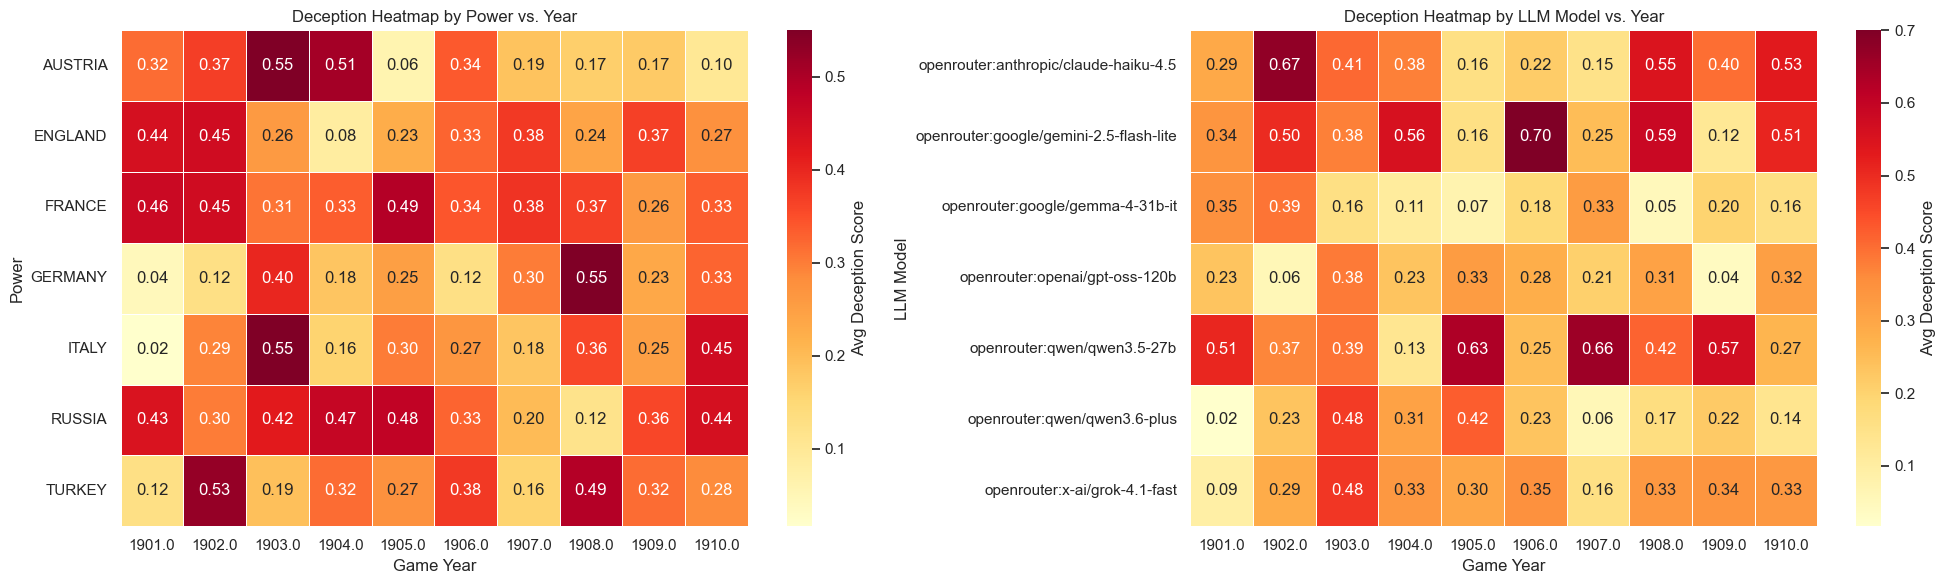

In [8]:
if has_deception:
    valid_dec["year"] = valid_dec["phase"].str.extract(r"(19\d{2})").astype(float)

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # By power
    hm_power = valid_dec.groupby(["power", "year"])["deception_score"].mean().reset_index()
    pivot_power = hm_power.pivot(index="power", columns="year", values="deception_score")
    sns.heatmap(pivot_power, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=0.5,
                cbar_kws={"label": "Avg Deception Score"}, ax=axes[0])
    axes[0].set_title("Deception Heatmap by Power vs. Year")
    axes[0].set_xlabel("Game Year")
    axes[0].set_ylabel("Power")

    # By model
    dec_with_model_hm = pd.merge(valid_dec, model_df, on=["game", "power"], how="inner")
    hm_model = dec_with_model_hm.groupby(["model_name", "year"])["deception_score"].mean().reset_index()
    pivot_model = hm_model.pivot(index="model_name", columns="year", values="deception_score")
    sns.heatmap(pivot_model, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=0.5,
                cbar_kws={"label": "Avg Deception Score"}, ax=axes[1])
    axes[1].set_title("Deception Heatmap by LLM Model vs. Year")
    axes[1].set_xlabel("Game Year")
    axes[1].set_ylabel("LLM Model")

    plt.tight_layout()
    plt.show()
else:
    print("Skipped: deception_scores.csv not available.")

---
# Part 2: Error & Reliability Analysis
This section analyses the operational reliability of the LLM agents: how often do they produce invalid orders, fail to parse JSON, or encounter API errors? These errors directly impact game outcomes since failed order generation results in HOLD fallbacks.

**Note:** Authentication errors are excluded from all error metrics below since they are infrastructure failures (API key/rate limit issues), not model failures.

## 2.1 Overall Error Rate by Response Type
Each LLM call is logged with a success status. We categorise outcomes across all response types.

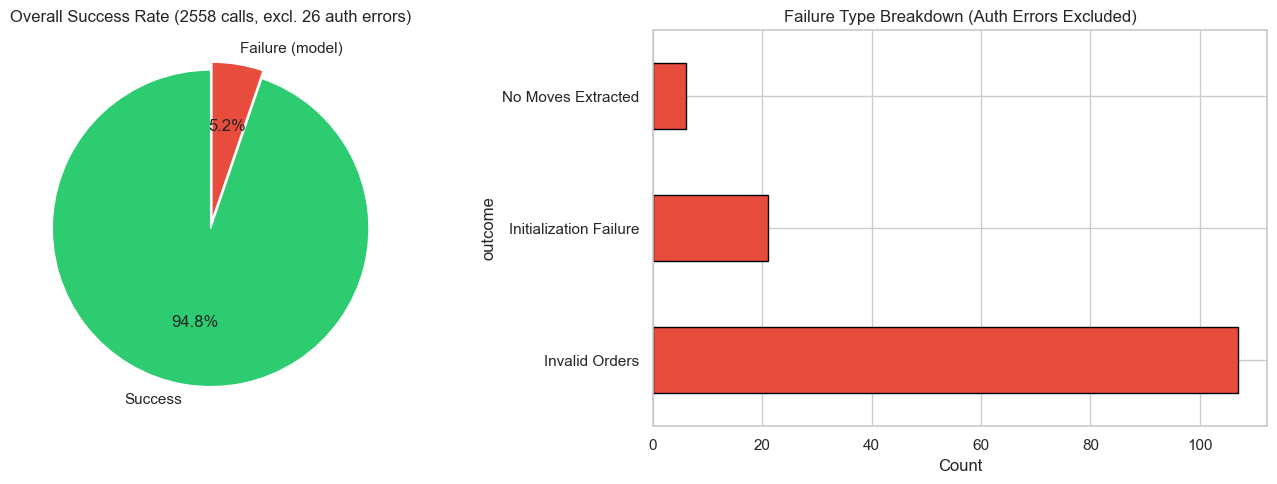


Outcome counts (excluding 26 auth errors — not a model fault):
  Success                    2424 (94.8%)
  Invalid Orders              107 (4.2%)
  Initialization Failure       21 (0.8%)
  No Moves Extracted            6 (0.2%)


In [9]:
def categorize_success(s):
    s = str(s)
    if s.startswith("Success") or s == "TRUE" or s.startswith("Using prompt"):
        return "Success"
    elif "Invalid LLM Moves" in s:
        return "Invalid Orders"
    elif "No moves extracted" in s:
        return "No Moves Extracted"
    elif "AuthenticationError" in s:
        return "Auth Error"
    elif s.startswith("Failure: Initialized"):
        return "Initialization Failure"
    elif s.startswith("Failure: Exception"):
        return "API Exception"
    else:
        return "Other Failure"

resp_df["outcome"] = resp_df["success"].apply(categorize_success)

# Auth errors are infrastructure failures, not model failures — exclude from error analysis
n_auth = (resp_df["outcome"] == "Auth Error").sum()
resp_no_auth = resp_df[resp_df["outcome"] != "Auth Error"].copy()

outcome_counts = resp_no_auth["outcome"].value_counts()
total = len(resp_no_auth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fail_mask = resp_no_auth["outcome"] != "Success"
pie_data = pd.Series({"Success": (~fail_mask).sum(), "Failure (model)": fail_mask.sum()})
pie_data.plot(kind="pie", ax=axes[0], autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
              startangle=90, explode=(0, 0.05))
axes[0].set_ylabel("")
axes[0].set_title(f"Overall Success Rate ({total} calls, excl. {n_auth} auth errors)")

fail_breakdown = resp_no_auth[fail_mask]["outcome"].value_counts()
fail_breakdown.plot(kind="barh", ax=axes[1], color="#e74c3c", edgecolor="black")
axes[1].set_xlabel("Count")
axes[1].set_title("Failure Type Breakdown (Auth Errors Excluded)")

plt.tight_layout()
plt.show()

print(f"\nOutcome counts (excluding {n_auth} auth errors — not a model fault):")
for outcome, count in outcome_counts.items():
    print(f"  {outcome:25s} {count:5d} ({count/total:.1%})")

## 2.2 Error Rates by Response Type
Different call types (order generation, negotiation, diary) may have vastly different failure modes.

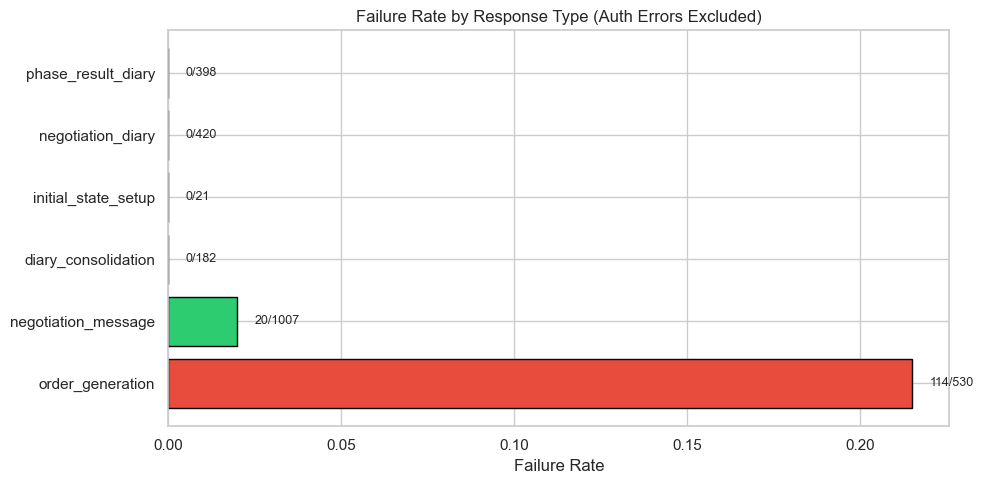

In [10]:
type_outcome = resp_no_auth.groupby(["response_type", "outcome"]).size().reset_index(name="count")
type_total = resp_no_auth.groupby("response_type").size().reset_index(name="total")
type_fail = resp_no_auth[resp_no_auth["outcome"] != "Success"].groupby("response_type").size().reset_index(name="failures")
type_stats = pd.merge(type_total, type_fail, on="response_type", how="left").fillna(0)
type_stats["failure_rate"] = type_stats["failures"] / type_stats["total"]
type_stats = type_stats.sort_values("failure_rate", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if r > 0.1 else "#f39c12" if r > 0.05 else "#2ecc71" 
          for r in type_stats["failure_rate"]]
ax.barh(type_stats["response_type"], type_stats["failure_rate"], color=colors, edgecolor="black")
ax.set_xlabel("Failure Rate")
ax.set_title("Failure Rate by Response Type (Auth Errors Excluded)")
for i, (_, row) in enumerate(type_stats.iterrows()):
    ax.text(row["failure_rate"] + 0.005, i, f"{row['failures']:.0f}/{row['total']:.0f}",
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 2.3 Invalid Order Analysis
When the LLM proposes orders that don't match the game engine's possible orders, they are flagged as invalid and replaced with HOLD fallbacks. Let's examine what kinds of invalid orders the models produce.

/var/folders/94/c6n86z4n7mzdqsymcrqq9bhr0000gn/T/ipykernel_51010/1836844072.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_order_stats, x="invalid_rate", y="model_name", palette="YlOrRd", edgecolor="black")


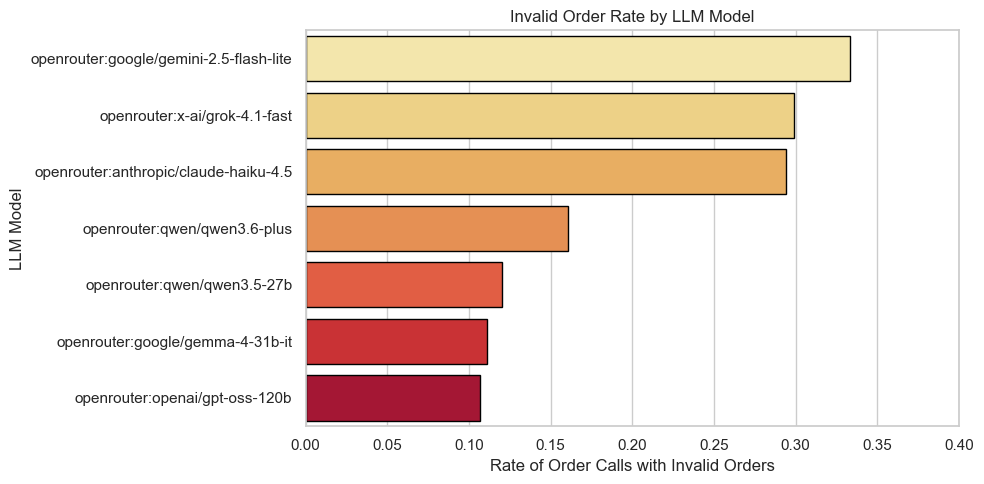

                             model_name  total_calls  invalid_count  total_invalid_orders  invalid_rate
openrouter:google/gemini-2.5-flash-lite           75             25                    62      0.333333
          openrouter:x-ai/grok-4.1-fast           77             23                    39      0.298701
  openrouter:anthropic/claude-haiku-4.5           68             20                    23      0.294118
           openrouter:qwen/qwen3.6-plus           81             13                    21      0.160494
            openrouter:qwen/qwen3.5-27b           83             10                    11      0.120482
       openrouter:google/gemma-4-31b-it           72              8                     9      0.111111
         openrouter:openai/gpt-oss-120b           75              8                    10      0.106667


In [11]:
# Extract invalid order details from success column
order_df = resp_df[resp_df["response_type"] == "order_generation"].copy()

def extract_invalid_orders(s):
    s = str(s)
    match = re.search(r"Invalid LLM Moves \((\d+)\): (.+)", s)
    if match:
        return int(match.group(1)), match.group(2)
    return 0, ""

order_df[["n_invalid", "invalid_orders_str"]] = order_df["success"].apply(
    lambda s: pd.Series(extract_invalid_orders(s)))

# Merge with model info
order_with_model = pd.merge(order_df, model_df, on=["game", "power"], how="left")

# Error rate by model
model_order_stats = order_with_model.groupby("model_name").agg(
    total_calls=("outcome", "count"),
    invalid_count=("n_invalid", lambda x: (x > 0).sum()),
    total_invalid_orders=("n_invalid", "sum")
).reset_index()
model_order_stats["invalid_rate"] = model_order_stats["invalid_count"] / model_order_stats["total_calls"]
model_order_stats = model_order_stats.sort_values("invalid_rate", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=model_order_stats, x="invalid_rate", y="model_name", palette="YlOrRd", edgecolor="black")
plt.xlabel("Rate of Order Calls with Invalid Orders")
plt.ylabel("LLM Model")
plt.title("Invalid Order Rate by LLM Model")
plt.xlim(0, max(model_order_stats["invalid_rate"].max() * 1.2, 0.1))
plt.tight_layout()
plt.show()

print(model_order_stats[["model_name", "total_calls", "invalid_count", "total_invalid_orders", "invalid_rate"]].to_string(index=False))

## 2.4 Common Invalid Order Patterns
What types of mistakes do the LLMs make? We categorize the most frequent invalid orders.

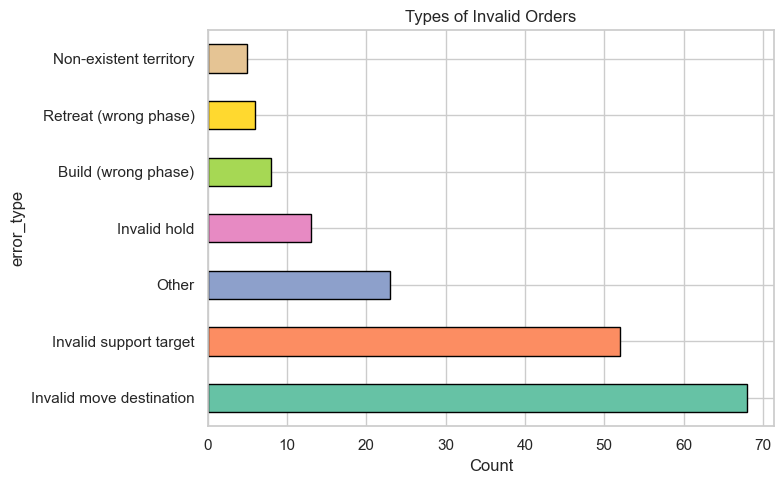


Top 15 most common invalid orders:
   11x  F BUL/EC - GRE
    7x  F AEG S F BUL/EC - GRE
    6x  A SER S F BUL/EC - GRE
    5x  F STP/SC - SWE
    5x  F STP/NC - BOT
    4x  A TYR - SWI
    4x  F BUL/EC - SMY
    4x  F STP/SC - SKA
    3x  F BRE - NTH
    3x  F TYS S F ION - GRE
    3x  A VIE S A GAL H
    3x  F DEN S F NTH - ENG
    3x  F SKA S F NTH - ENG
    2x  A PAR - BUR
    2x  A MAR - SPA


In [12]:
# Collect all invalid orders
all_invalid = []
for _, row in order_df[order_df["n_invalid"] > 0].iterrows():
    orders_str = row["invalid_orders_str"]
    for order in orders_str.split(", "):
        order = order.strip()
        if order:
            all_invalid.append({"game": row["game"], "power": row["power"],
                                "phase": row["phase"], "invalid_order": order})

inv_df = pd.DataFrame(all_invalid)

if not inv_df.empty:
    def classify_invalid(order):
        order = str(order).strip()
        if order.endswith(" B") or " B " in order:
            return "Build (wrong phase)"
        if order.endswith(" R ") or re.search(r"\bR\b", order):
            return "Retreat (wrong phase)"
        if "SWI" in order or "SAH" in order or "SIB" in order:
            return "Non-existent territory"
        if re.search(r"S [AF] .+ - .+", order):
            return "Invalid support target"
        if " - " in order:
            return "Invalid move destination"
        if order.endswith(" H"):
            return "Invalid hold"
        return "Other"

    inv_df["error_type"] = inv_df["invalid_order"].apply(classify_invalid)

    error_counts = inv_df["error_type"].value_counts()
    plt.figure(figsize=(8, 5))
    error_counts.plot(kind="barh", color=sns.color_palette("Set2", len(error_counts)), edgecolor="black")
    plt.xlabel("Count")
    plt.title("Types of Invalid Orders")
    plt.tight_layout()
    plt.show()

    print("\nTop 15 most common invalid orders:")
    for order, count in Counter(inv_df["invalid_order"]).most_common(15):
        print(f"  {count:3d}x  {order}")
else:
    print("No invalid orders found in the dataset.")

## 2.5 Order Success Rate from Game Engine
Beyond LLM parsing errors, we can also check how often *valid* orders actually succeed on the board (vs. being bounced, dislodged, or cut by other powers).

/var/folders/94/c6n86z4n7mzdqsymcrqq9bhr0000gn/T/ipykernel_51010/1952616228.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=power_success, x="success_rate", y="power", palette="RdYlGn", ax=axes[0], edgecolor="black")
/var/folders/94/c6n86z4n7mzdqsymcrqq9bhr0000gn/T/ipykernel_51010/1952616228.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_success, x="success_rate", y="model_name", palette="RdYlGn", ax=axes[1], edgecolor="black")


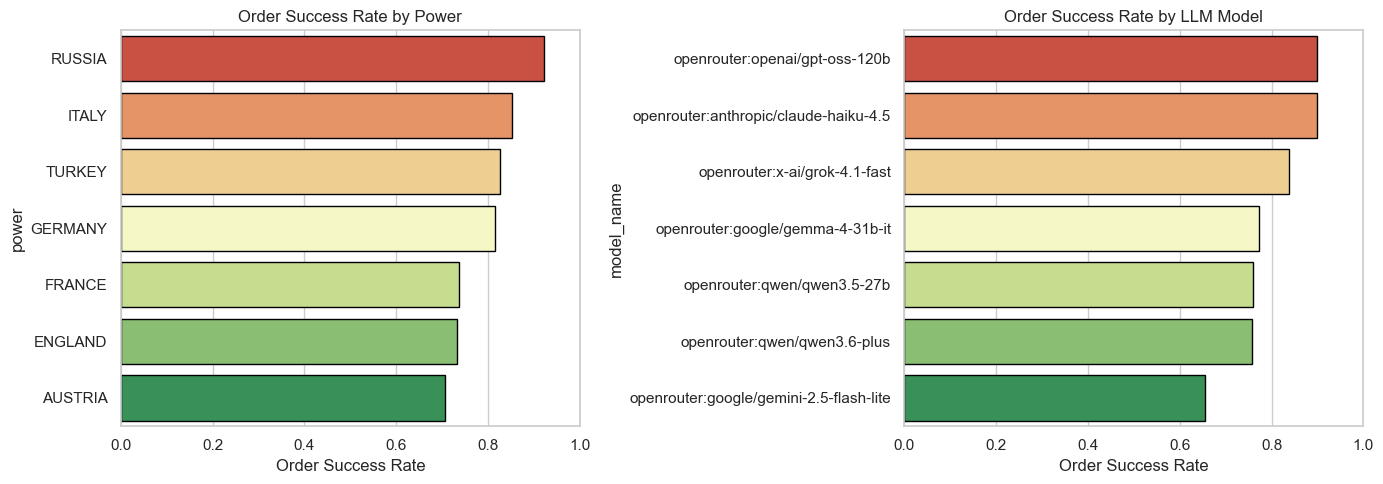


Overall order success rate: 79.8%
Total orders executed: 1893


In [13]:
# Load order results from lmvsgame.json
order_results = []
for game in games:
    game_path = os.path.join(base_path, game, "lmvsgame.json")
    if not os.path.exists(game_path):
        continue
    with open(game_path, "r") as f:
        game_data = json.load(f)
    for phase in game_data.get("phases", []):
        if not phase["name"].endswith("M"):
            continue
        for power, results in phase.get("order_results", {}).items():
            for order_type, orders_list in results.items():
                for order_info in orders_list:
                    order_results.append({
                        "game": game,
                        "phase": phase["name"],
                        "power": power,
                        "order_type": order_type,
                        "order": order_info.get("order", ""),
                        "result": order_info.get("result", "unknown")
                    })

or_df = pd.DataFrame(order_results)

if not or_df.empty:
    # Success rate by power
    or_df["succeeded"] = or_df["result"] == "success"
    power_success = or_df.groupby("power").agg(
        total=("succeeded", "count"),
        successes=("succeeded", "sum")
    ).reset_index()
    power_success["success_rate"] = power_success["successes"] / power_success["total"]
    power_success = power_success.sort_values("success_rate", ascending=False)

    # Merge with model info to see by model
    or_with_model = pd.merge(or_df, model_df, on=["game", "power"], how="left")
    model_success = or_with_model.groupby("model_name").agg(
        total=("succeeded", "count"),
        successes=("succeeded", "sum")
    ).reset_index()
    model_success["success_rate"] = model_success["successes"] / model_success["total"]
    model_success = model_success.sort_values("success_rate", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=power_success, x="success_rate", y="power", palette="RdYlGn", ax=axes[0], edgecolor="black")
    axes[0].set_xlabel("Order Success Rate")
    axes[0].set_title("Order Success Rate by Power")
    axes[0].set_xlim(0, 1)

    sns.barplot(data=model_success, x="success_rate", y="model_name", palette="RdYlGn", ax=axes[1], edgecolor="black")
    axes[1].set_xlabel("Order Success Rate")
    axes[1].set_title("Order Success Rate by LLM Model")
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

    print(f"\nOverall order success rate: {or_df['succeeded'].mean():.1%}")
    print(f"Total orders executed: {len(or_df)}")
else:
    print("No order result data found.")

## 2.6 Error Timeline: Failures Over Game Phases
Do errors cluster at certain points in the game? Long context windows in later phases or complex board states might cause more failures.

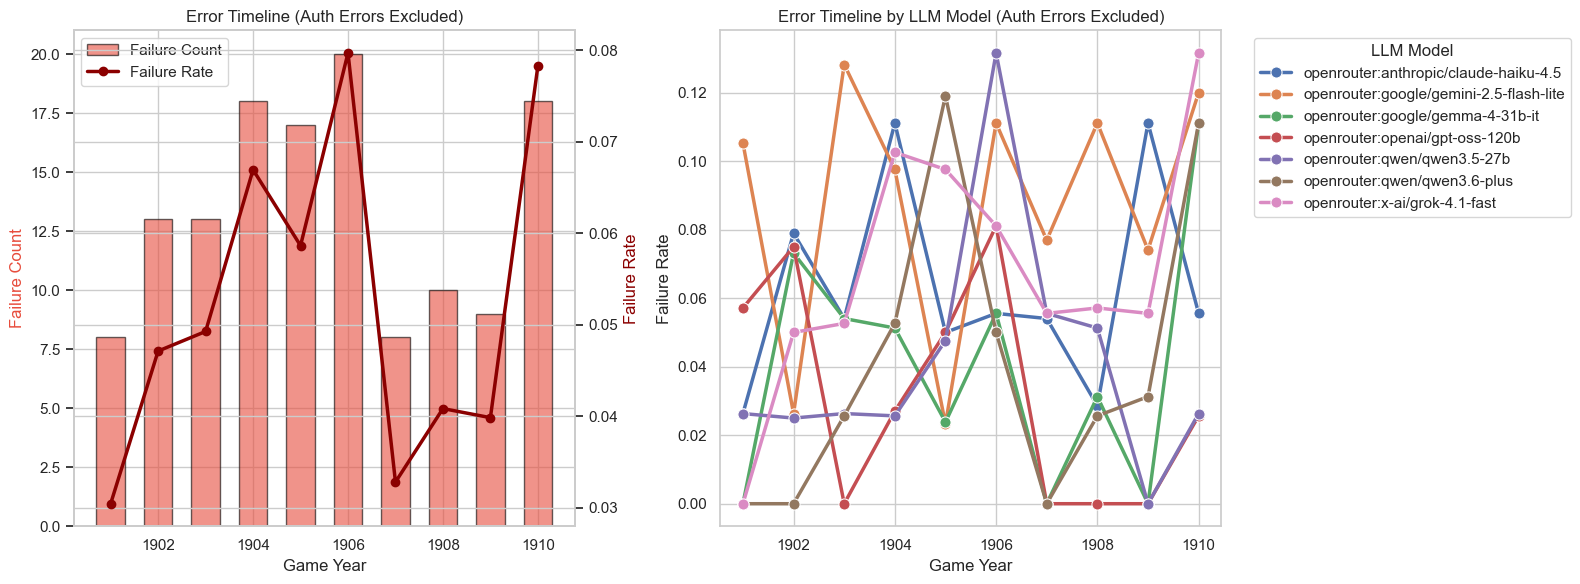

In [14]:
resp_no_auth["year"] = resp_no_auth["phase"].str.extract(r"(19\d{2})").astype(float)
resp_no_auth["is_failure"] = resp_no_auth["outcome"] != "Success"

year_errors = resp_no_auth.groupby("year").agg(
    total=("is_failure", "count"),
    failures=("is_failure", "sum")
).reset_index()
year_errors["failure_rate"] = year_errors["failures"] / year_errors["total"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Aggregate timeline
ax2 = axes[0].twinx()
axes[0].bar(year_errors["year"], year_errors["failures"], alpha=0.6, color="#e74c3c",
            label="Failure Count", edgecolor="black", width=0.6)
ax2.plot(year_errors["year"], year_errors["failure_rate"], color="darkred",
         marker="o", linewidth=2.5, label="Failure Rate")
axes[0].set_xlabel("Game Year")
axes[0].set_ylabel("Failure Count", color="#e74c3c")
ax2.set_ylabel("Failure Rate", color="darkred")
axes[0].set_title("Error Timeline (Auth Errors Excluded)")
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# By model
resp_no_auth_model = pd.merge(resp_no_auth, model_df, on=["game", "power"], how="inner")
model_year_err = resp_no_auth_model.groupby(["model_name", "year"]).agg(
    total=("is_failure", "count"),
    failures=("is_failure", "sum")
).reset_index()
model_year_err["failure_rate"] = model_year_err["failures"] / model_year_err["total"]

sns.lineplot(data=model_year_err, x="year", y="failure_rate", hue="model_name",
             marker="o", linewidth=2.5, markersize=8, ax=axes[1])
axes[1].set_xlabel("Game Year")
axes[1].set_ylabel("Failure Rate")
axes[1].set_title("Error Timeline by LLM Model (Auth Errors Excluded)")
axes[1].legend(title="LLM Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 2.7 Model Reliability Scorecard
A comprehensive comparison of each model's operational reliability across all call types.

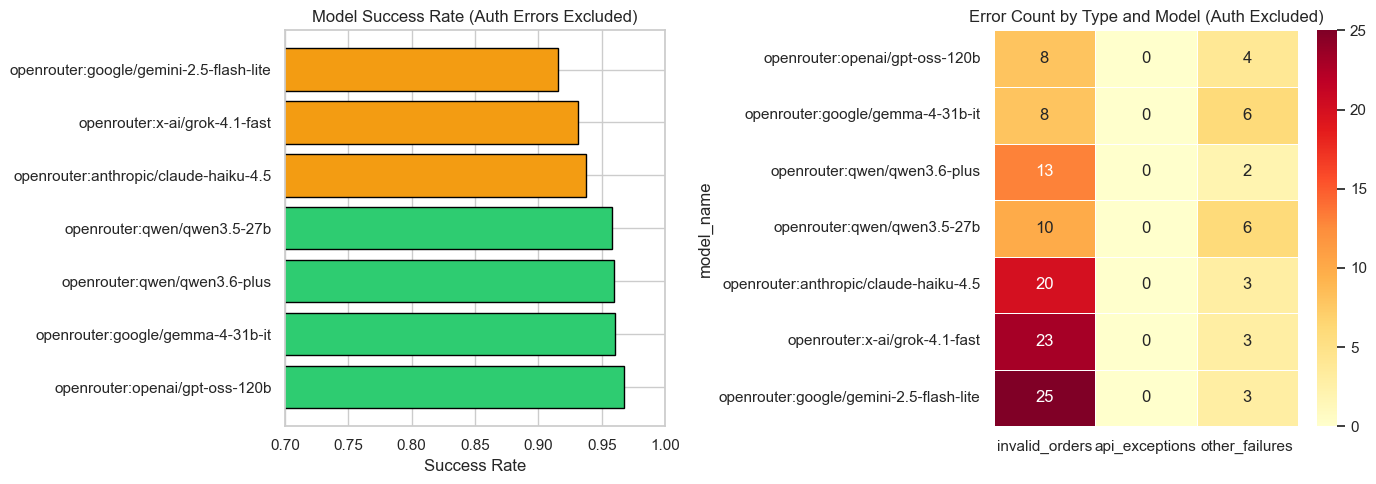

                             model_name  total_calls  success_rate  invalid_orders
         openrouter:openai/gpt-oss-120b          372      0.967742               8
       openrouter:google/gemma-4-31b-it          352      0.960227               8
           openrouter:qwen/qwen3.6-plus          372      0.959677              13
            openrouter:qwen/qwen3.5-27b          384      0.958333              10
  openrouter:anthropic/claude-haiku-4.5          369      0.937669              20
          openrouter:x-ai/grok-4.1-fast          378      0.931217              23
openrouter:google/gemini-2.5-flash-lite          331      0.915408              25


In [15]:
resp_no_auth_with_model = pd.merge(resp_no_auth, model_df, on=["game", "power"], how="left")

model_reliability = resp_no_auth_with_model.groupby("model_name").agg(
    total_calls=("outcome", "count"),
    successes=("outcome", lambda x: (x == "Success").sum()),
    invalid_orders=("outcome", lambda x: (x == "Invalid Orders").sum()),
    api_exceptions=("outcome", lambda x: (x == "API Exception").sum()),
    other_failures=("outcome", lambda x: x.isin(["No Moves Extracted", "Initialization Failure", "Other Failure"]).sum()),
).reset_index()
model_reliability["success_rate"] = model_reliability["successes"] / model_reliability["total_calls"]
model_reliability = model_reliability.sort_values("success_rate", ascending=False)

display_cols = ["invalid_orders", "api_exceptions", "other_failures"]
hm_data = model_reliability.set_index("model_name")[display_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2ecc71" if r > 0.95 else "#f39c12" if r > 0.85 else "#e74c3c"
          for r in model_reliability["success_rate"]]
axes[0].barh(model_reliability["model_name"], model_reliability["success_rate"],
             color=colors, edgecolor="black")
axes[0].set_xlabel("Success Rate")
axes[0].set_title("Model Success Rate (Auth Errors Excluded)")
axes[0].set_xlim(0.7, 1.0)

sns.heatmap(hm_data, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, ax=axes[1])
axes[1].set_title("Error Count by Type and Model (Auth Excluded)")

plt.tight_layout()
plt.show()

print(model_reliability[["model_name", "total_calls", "success_rate", "invalid_orders"]].to_string(index=False))

---
# Part 3: Combined Insights
Cross-referencing deception patterns with error data reveals whether unreliable models also tend to be more or less deceptive, and whether errors correlate with game outcomes.

## 3.1 Reliability vs. Deception vs. Game Outcome
A scatter plot combining all three dimensions: does a reliable and deceptive model win?

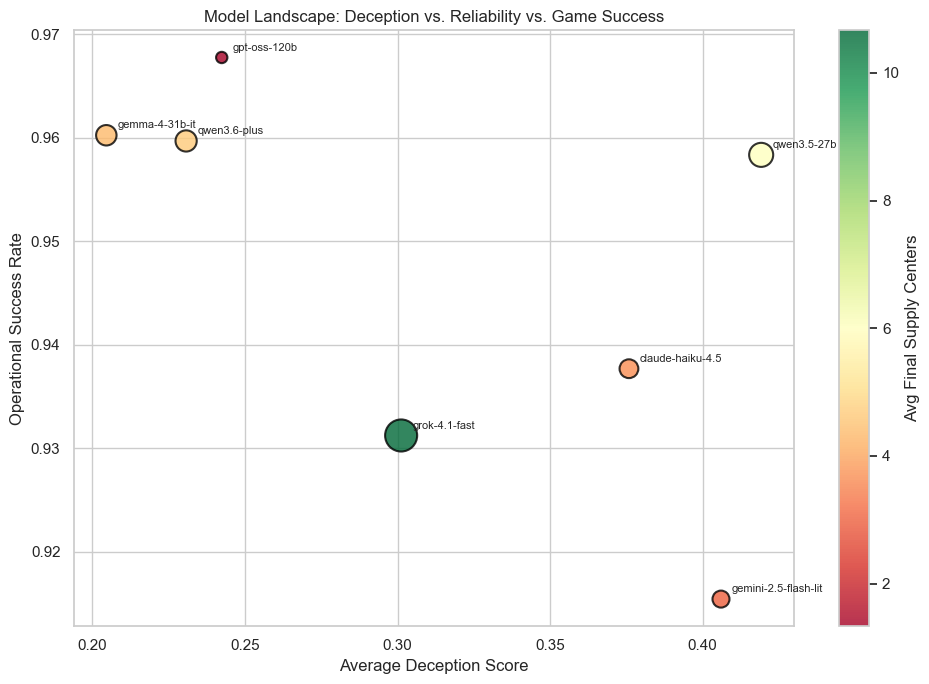

In [16]:
if has_deception:
    dec_by_model = pd.merge(valid_dec, model_df, on=["game", "power"], how="inner")
    dec_by_model = dec_by_model.groupby("model_name")["deception_score"].mean().reset_index()
    dec_by_model.rename(columns={"deception_score": "avg_deception"}, inplace=True)

    reliability_slim = model_reliability[["model_name", "success_rate"]].copy()

    sc_with_model = pd.merge(sc_df, model_df, on=["game", "power"], how="inner")
    sc_by_model = sc_with_model.groupby("model_name")["final_sc"].mean().reset_index()

    combined = pd.merge(dec_by_model, reliability_slim, on="model_name")
    combined = pd.merge(combined, sc_by_model, on="model_name")

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(combined["avg_deception"], combined["success_rate"],
                          s=combined["final_sc"] * 50, c=combined["final_sc"],
                          cmap="RdYlGn", edgecolor="black", linewidth=1.5, alpha=0.8)
    plt.colorbar(scatter, label="Avg Final Supply Centers")
    for _, row in combined.iterrows():
        short_name = row["model_name"].split("/")[-1][:20]
        plt.annotate(short_name, (row["avg_deception"], row["success_rate"]),
                     textcoords="offset points", xytext=(8, 5), fontsize=8)
    plt.xlabel("Average Deception Score")
    plt.ylabel("Operational Success Rate")
    plt.title("Model Landscape: Deception vs. Reliability vs. Game Success")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: deception_scores.csv not available for combined analysis.")

## 3.2 Error Impact on Game Outcomes
Do powers with more LLM failures end up with fewer supply centers? Errors cause HOLD fallbacks, which waste strategic opportunities.

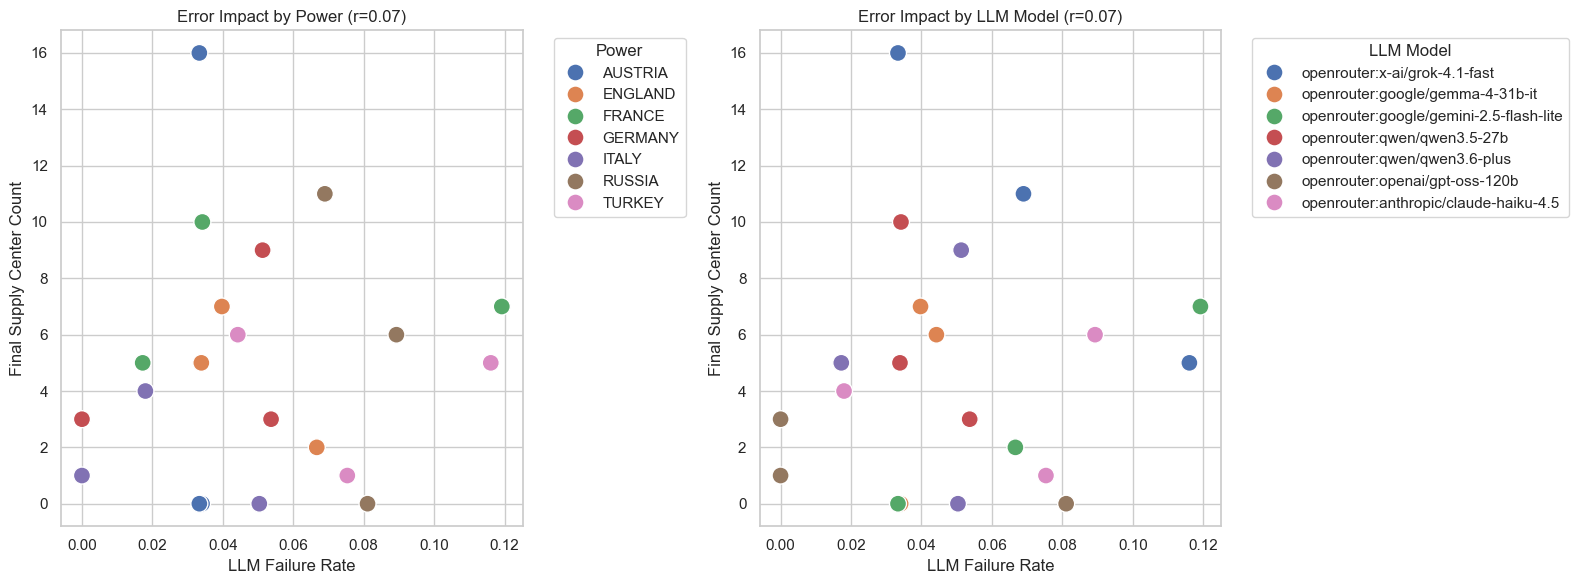

Correlation (failure rate vs supply centers, auth errors excluded):
  By power: r = 0.07
  By model: r = 0.07


In [17]:
power_errors = resp_no_auth.groupby(["game", "power"]).agg(
    total=("is_failure", "count"),
    failures=("is_failure", "sum")
).reset_index()
power_errors["failure_rate"] = power_errors["failures"] / power_errors["total"]

error_outcome = pd.merge(power_errors, sc_df, on=["game", "power"])
error_outcome_model = pd.merge(error_outcome, model_df, on=["game", "power"], how="inner")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By power
sns.scatterplot(data=error_outcome, x="failure_rate", y="final_sc", hue="power", s=150, ax=axes[0])
corr_p = error_outcome["failure_rate"].corr(error_outcome["final_sc"])
axes[0].set_xlabel("LLM Failure Rate")
axes[0].set_ylabel("Final Supply Center Count")
axes[0].set_title(f"Error Impact by Power (r={corr_p:.2f})")
axes[0].legend(title="Power", bbox_to_anchor=(1.05, 1), loc="upper left")

# By model
sns.scatterplot(data=error_outcome_model, x="failure_rate", y="final_sc",
                hue="model_name", s=150, ax=axes[1])
corr_m = error_outcome_model["failure_rate"].corr(error_outcome_model["final_sc"])
axes[1].set_xlabel("LLM Failure Rate")
axes[1].set_ylabel("Final Supply Center Count")
axes[1].set_title(f"Error Impact by LLM Model (r={corr_m:.2f})")
axes[1].legend(title="LLM Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(f"Correlation (failure rate vs supply centers, auth errors excluded):")
print(f"  By power: r = {corr_p:.2f}")
print(f"  By model: r = {corr_m:.2f}")

---
# Conclusion

## Deception Findings

- **Low overall deception:** The mean deception score across all 401 analysed power/phases was **0.31** (median 0.15), with a strong right skew — most interactions are honest, but a meaningful tail of deceptive behaviour exists.
- **Model personality matters:** Qwen 3.5-27B was the most deceptive model (avg 0.42), closely followed by Gemini 2.5 Flash Lite (0.41) and Claude Haiku 4.5 (0.38). Gemma 4-31B (0.20) and Qwen 3.6 Plus (0.23) were the most honest — roughly half as deceptive as the leaders.
- **Deception slightly hurts:** The correlation between average deception and final supply centers was weakly negative (r = -0.17), suggesting deception provides no advantage and may even be counterproductive.
- **Strong promise-keeping:** Agents kept 83.8% of their commitments (1,409 kept vs. 273 broken), indicating that even when deception occurs, it is selective rather than pervasive.

## Error & Reliability Findings

- **High baseline reliability:** After excluding 26 auth errors (infrastructure, not model failures), the overall success rate was **94.8%** across 2,558 LLM calls.
- **GPT-oss-120B was the most reliable** at 96.8% success rate, followed by Gemma 4-31B (96.0%) and Qwen 3.6 Plus (96.0%).
- **Gemini 2.5 Flash Lite had the highest invalid order rate:** 33.3% of its order-generation calls contained at least one invalid move, followed by Grok 4.1 Fast (29.9%) and Claude Haiku 4.5 (29.4%).
- **Coast-specific hallucinations dominate:** The most common invalid orders involved `F BUL/EC - GRE` (11 occurrences) and `F STP/SC` variants — coast specification errors that the game engine rejects.
- **Errors do not predict outcomes:** The correlation between failure rate and final supply centers was r = 0.07 — essentially zero in both directions. Errors simply do not determine game success.
- **Order execution success was 79.8%:** Beyond LLM parsing, only about 4 in 5 valid orders actually succeeded on the board (the rest were bounced, cut, or dislodged by opponents).

## Cross-Cutting Insight

Neither deception nor reliability predicted game outcomes. The deception-outcome correlation was weakly negative (r = -0.17), and the error-outcome correlation was negligible (r = 0.07). This suggests that **strategic diplomacy and communication volume are far more important than either honesty or operational precision** in these 3-game experiments (see playstyle analysis where messaging correlates r = 0.61 with outcomes).